# Mining Process – % Silica Concentrate Prediction

This project aims to develop a **machine learning regression model** to predict the **% Silica Concentrate** in a mining flotation process using operational plant data.  
Accurate prediction of silica concentration is essential to improve process efficiency, reduce laboratory dependency, and support real-time decision-making in the field. The code is divided into five main parts, which are:
1. Imports & Configurations;
2. Dataset Treatment;  
3. Applying Ensemble Model; 
4. Result Analysis;
5. Predicting the Future.


**Responsible:** Paulo Casmal

**Email:** <paulo.casmal@gmail.com>

**Start Date:** 01-31-2026 | **Submission Date:** 


---


## 01 - Imports & Configurations

In [63]:
# import necessary libraries
import locale
import pandas as pd
import numpy as np  
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# import machine learning models to compare performance
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.tsa.arima.model import ARIMA
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

In [64]:
# Configuration of matplotlib parameters for consistent styling
mpl.rcParams['figure.figsize'] = (10, 5)  # Default figure size
mpl.rc('lines', lw=2)  # Sets the line width
mpl.rcParams['grid.linewidth'] = 0.5  # Grid line width
mpl.rcParams['grid.linestyle'] = 'dashed'  # Grid line style
mpl.rc(('xtick', 'ytick'), labelsize=15)  # Axis tick label size
mpl.rc('font', family='Arial', size=15)  # Font family and font size
mpl.rcParams['axes.linewidth'] = 0.5 # - Largura das bordas dos gráficos

In [65]:
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8') 
except:
    locale.setlocale(locale.LC_ALL, 'portuguese_brazil')

# 2. Informa ao Matplotlib para usar o separador do locale
mpl.rcParams['axes.formatter.use_locale'] = True

In [66]:
# Load the dataset
path = r'C:\Users\paulo\Downloads\archive (2)\MiningProcess_Flotation_Plant_Database.csv'

df = pd.read_csv(path, decimal=',')

df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 02 - Dataset treatment

In [67]:
# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [68]:
df.columns

Index(['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')

Drop the '% Iron Concentrate' column due to high correlation with target variable. Additionaly, this variable can be measured only at laboratory, which not helps to predict the '% Silica Concentrate' in field.

In [69]:
df = df[['% Iron Concentrate', '% Silica Concentrate']]

In [70]:
df = df.resample("1H").mean()

In [71]:
df = df.drop_duplicates(keep='first')

EDA was performed in a separate script. It does not indicate any major problem with data.

In [72]:
df = df.rename(columns={'% Iron Concentrate': 'Iron_Concentrate', '% Silica Concentrate': 'Silica_Concentrate'})

### 2.3 - Lag Features

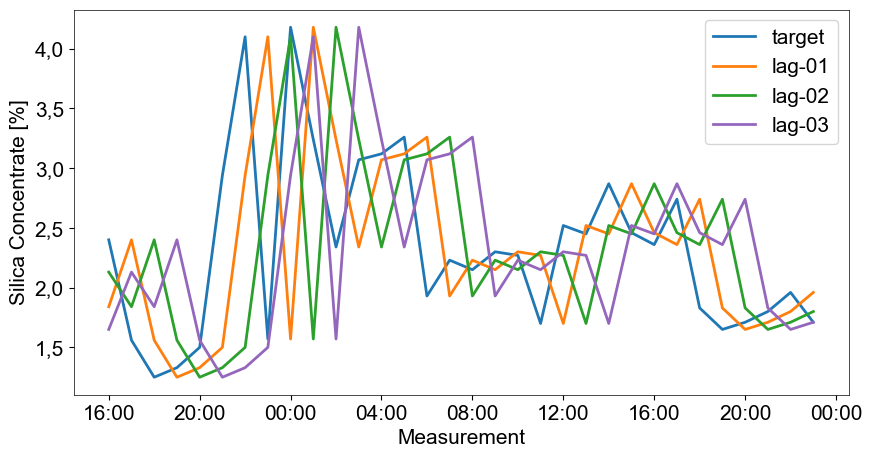

In [73]:
# Just for visualization purposes
view = df.sort_index().copy()

view = view[view.index > '2017-09-08 00:00:00']

target_col = "Silica_Concentrate"

for lag in range(1, 15):
    view[f"lag-{lag}"] = view[target_col].shift(lag)

view = view.dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(view.index, view['Silica_Concentrate'], label='target')
ax.plot(view.index, view['lag-1'], c='tab:orange', label='lag-01')
ax.plot(view.index, view['lag-2'], c='tab:green', label='lag-02')
ax.plot(view.index, view['lag-3'], c='tab:purple', label='lag-03')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.legend()
ax.set_ylabel('Silica Concentrate [%]')
ax.set_xlabel('Measurement')

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\lag-features.svg', dpi=140, format='svg', transparent=True)

plt.show()


In [74]:
df = df.sort_index()

target_col = "Silica_Concentrate"

for col in df.columns:
    for lag in range(1, 15):
        df[f"{col}-lag-{lag}"] = df[col].shift(lag)

df = df.dropna()

In [75]:
df = df.drop(columns=['Iron_Concentrate'])

### 2.4 - Cross-Validation

In [76]:
# Using specific time series train test split method
tss = TimeSeriesSplit(n_splits=5, test_size=24*14, gap=24) # 14 days data for testing

df = df.sort_index()

df = df.dropna()

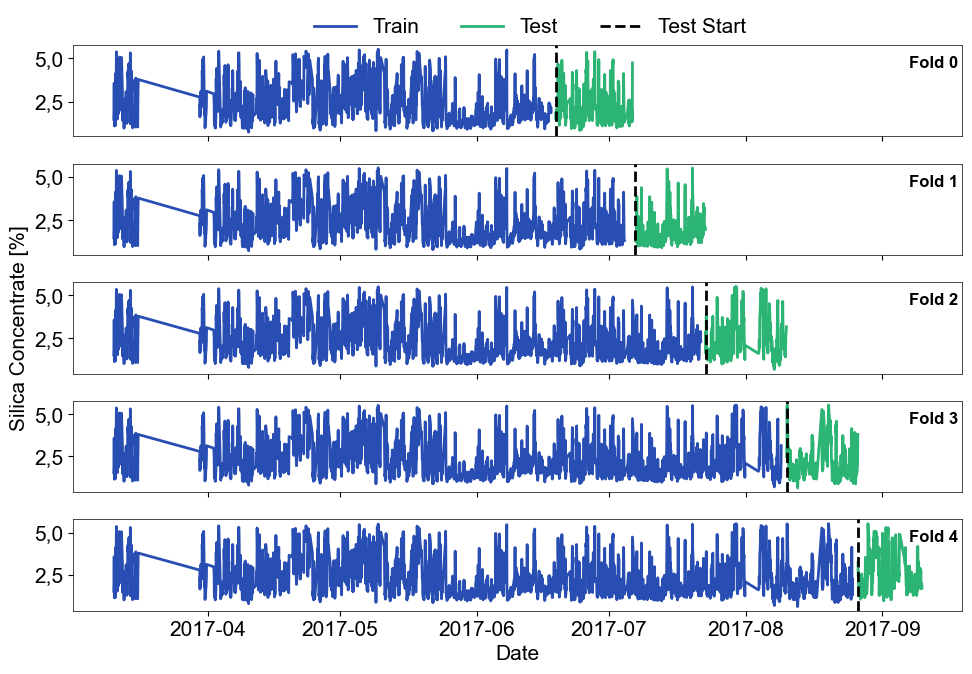

In [77]:
# Just for visualization purposes
fig, axs = plt.subplots(5, 1, figsize=(10, 7), sharex=True)

# Plot each fold
for fold, (train_index, test_index) in enumerate(tss.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    axs[fold].plot(train.index, train['Silica_Concentrate'], label='Train', c='#294EB3')
    axs[fold].plot(test.index, test['Silica_Concentrate'], label='Test', c="#2BB473")
    axs[fold].axvline(x=test.index[0], color='k', linestyle='--', label='Test Start')

    axs[fold].text(0.94, 0.75, f'Fold {fold}', fontsize=12, transform=axs[fold].transAxes, fontweight='bold')


axs[2].set_ylabel('Silica Concentrate [%]')

axs[0].legend(ncol=3, loc='upper left', bbox_to_anchor=(0.25, 1.5), frameon=False)

plt.xlabel('Date')
plt.tight_layout()

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\time-series-split.svg', dpi=140, format='svg', transparent=True)

plt.show()

### 2.5 - StandardScaler

In [78]:
# # Just for visualization purposes
# df_sc = df.copy()

# X_view_train = df_sc.drop(columns=['Silica_Concentrate'])


# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_view_train)

# print(
#     f"\nBefore transformation\n"
#     f"max: {X_view_train['% Silica Feed'].max().round(2)} | "
#     f"min: {X_view_train['% Silica Feed'].min().round(2)} | "
#     f"std: {X_view_train['% Silica Feed'].std().round(2)}"
# )

# X_train_scaled = pd.DataFrame(
#     X_train_scaled,
#     columns=X_view_train.columns,
#     index=X_view_train.index
# )

# print(
#     f"\nAfter transformation\n"
#     f"max: {X_train_scaled['% Silica Feed'].max().round(2)} | "
#     f"min: {X_train_scaled['% Silica Feed'].min().round(2)} | "
#     f"std: {X_train_scaled['% Silica Feed'].std().round(2)}"
# )


### 2.6 - Principal Components Analysis

In [79]:
# # Just for visualization purposes
# pca = PCA().fit(X_train_scaled)

# fig_pca, ax = plt.subplots(figsize=(6, 5))

# ax.plot(np.cumsum(pca.explained_variance_ratio_), label='Cumulative Explained Variance', c='#0B1741')
# ax.axhline(0.95, linestyle='--', label='95% Explained Variance', color='#B2275F')

# ax.set_xlabel('Number of Components')
# ax.set_ylabel('Cumulative Explained Variance')
# ax.set_title('Explained Variance by PCA')

# ax.legend(loc=4)
# ax.set_ylim(0.2, 1)
# ax.set_xlim(0, 50)

# fig_pca.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\pca.svg', dpi=140, format='svg', transparent=True)

# plt.show()

## 03 - Applying Models

In [87]:
target = 'Silica_Concentrate'
lags_to_test = np.arange(1, 14, 3)

In [89]:
lags_to_test

array([ 1,  4,  7, 10, 13])

### 3.1 - XGBoost

In [81]:
all_results = []

# Definição do espaço de busca de hiperparâmetros
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 500, 800],
    'objective': ['reg:squarederror'],
    'random_state': [42]
}

for n_lags in lags_to_test:
    print(f"\n{'='*40}")
    print(f" EXPERIMENTO: {n_lags} LAGS + GRID SEARCH ")
    print(f"{'='*40}")

    # 1. Filtragem dinâmica de colunas
    cols_to_keep = [target]
    for i in range(1, n_lags + 1):
        cols_to_keep.append(f'Iron_Concentrate-lag-{i}')
        cols_to_keep.append(f'Silica_Concentrate-lag-{i}')
    
    df_filtered = df[cols_to_keep].copy()
    X = df_filtered.drop(columns=[target])
    y = df_filtered[target]

    # 2. Configuração do Cross-Validation para o Grid Search
    tss = TimeSeriesSplit(n_splits=5)
    
    # Instanciando o modelo base
    xgb_model = xgb.XGBRegressor()

    # 3. Execução do Grid Search
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        cv=tss,
        scoring='neg_root_mean_squared_error',
        verbose=1,
        n_jobs=-1 # Usa todos os núcleos do processador
    )

    grid_search.fit(X, y)

    # 4. Extração dos melhores resultados para este lag
    best_rmse = -grid_search.best_score_
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    # Calculando R2 e MAE com o melhor modelo (usando o último split para validação final)
    # Aqui simulamos a performance final para registro
    train_idx, test_idx = list(tss.split(X))[-1]
    y_pred = best_model.predict(X.iloc[test_idx])
    
    final_r2 = r2_score(y.iloc[test_idx], y_pred)
    final_mae = mean_absolute_error(y.iloc[test_idx], y_pred)

    print(f"Melhor RMSE ({n_lags} lags): {best_rmse:.4f}")
    print(f"Melhores Parâmetros: {best_params}")

    all_results.append({
        'n_lags': n_lags,
        'rmse_avg': best_rmse,
        'r2_avg': final_r2,
        'mae_avg': final_mae,
        'best_model_obj': best_model,
        'params': best_params
    })

# 5. Ranking Final
top_3_results = sorted(all_results, key=lambda x: x['rmse_avg'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MODELOS (PÓS-GRID SEARCH)")
print("#"*40)

for i, res in enumerate(top_3_results):
    print(f"{i+1}º Lugar: {res['n_lags']} Lags | RMSE: {res['rmse_avg']:.4f} | Params: {res['params']}")


 EXPERIMENTO: 1 LAGS + GRID SEARCH 
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Melhor RMSE (1 lags): 0.7435
Melhores Parâmetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'objective': 'reg:squarederror', 'random_state': 42}

 EXPERIMENTO: 4 LAGS + GRID SEARCH 
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Melhor RMSE (4 lags): 0.7394
Melhores Parâmetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'objective': 'reg:squarederror', 'random_state': 42}

 EXPERIMENTO: 7 LAGS + GRID SEARCH 
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Melhor RMSE (7 lags): 0.7425
Melhores Parâmetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'objective': 'reg:squarederror', 'random_state': 42}

 EXPERIMENTO: 10 LAGS + GRID SEARCH 
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Melhor RMSE (10 lags): 0.7365
Melhores Parâmetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500,

In [82]:
rmse_list_xgb = []
r2_list_xgb = []
mae_list_xgb = []
lags_xgb = []

for i in range(len(all_results)):
    lags_xgb.append(all_results[i]['n_lags'])
    rmse_list_xgb.append(all_results[i]['rmse_avg'])
    r2_list_xgb.append(all_results[i]['r2_avg'])
    mae_list_xgb.append(all_results[i]['mae_avg'])

### 3.2 - Random Forest

In [83]:
all_results_rf = []

param_grid_rf = {
    "n_estimators": [200, 500, 800],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 1.0],
    "random_state": [42]
}

# Holdout final: últimos 20% como teste (mantém ordem temporal)
test_size = 0.2

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO RANDOM FOREST: {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1) Filtrar colunas dinamicamente
    cols_to_keep = [target]
    for i in range(1, n_lags + 1):
        cols_to_keep.append(f'Iron_Concentrate-lag-{i}')
        cols_to_keep.append(f'Silica_Concentrate-lag-{i}')

    df_filtered = df[cols_to_keep].copy()

    X = df_filtered.drop(columns=[target])
    y = df_filtered[target]

    # 2) Split temporal (holdout)
    split_point = int(len(df_filtered) * (1 - test_size))

    X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
    y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

    # 3) GridSearch com CV time series APENAS no treino
    tss = TimeSeriesSplit(n_splits=5)

    base_rf = RandomForestRegressor(n_jobs=-1)

    grid = GridSearchCV(
        estimator=base_rf,
        param_grid=param_grid_rf,
        scoring="neg_root_mean_squared_error",
        cv=tss,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best_params = grid.best_params_
    best_rmse_cv = -grid.best_score_

    print(f"Melhores params (GridSearch) -> {best_params}")
    print(f"RMSE médio (CV no treino)    -> {best_rmse_cv:.4f}")

    # 4) Treina modelo final com melhores params no treino inteiro e avalia no holdout
    final_model = RandomForestRegressor(**best_params, n_jobs=-1)
    final_model.fit(X_train, y_train)

    y_pred = final_model.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))
    mae = float(mean_absolute_error(y_test, y_pred))

    print(f"Holdout Final ({n_lags} lags) -> RMSE: {rmse:.4f} | R²: {r2:.4f} | MAE: {mae:.4f}")

    all_results_rf.append({
        "n_lags_rfs": n_lags,
        "rmse_holdout_rfs": rmse,
        "r2_holdout_rfs": r2,
        "mae_holdout_rfs": mae,
        "model_obj_rfs": final_model,
        "params_rfs": best_params,
        "rmse_gridsearch_cv_rfs": best_rmse_cv
    })

# Rankear Top 3 pelo holdout (métrica final)
top_3_rf = sorted(all_results_rf, key=lambda x: x["rmse_holdout_rfs"])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - RANDOM FOREST (HOLDOUT)")
print("#"*40)
for i, res in enumerate(top_3_rf):
    print(f"{i+1}º Lugar: {res['n_lags_rfs']} Lags | RMSE Holdout: {res['rmse_holdout_rfs']:.4f}")



 TESTANDO RANDOM FOREST: 1 LAGS 
Melhores params (GridSearch) -> {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 800, 'random_state': 42}
RMSE médio (CV no treino)    -> 0.7517
Holdout Final (1 lags) -> RMSE: 0.7233 | R²: 0.6123 | MAE: 0.5225

 TESTANDO RANDOM FOREST: 2 LAGS 
Melhores params (GridSearch) -> {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 800, 'random_state': 42}
RMSE médio (CV no treino)    -> 0.7294
Holdout Final (2 lags) -> RMSE: 0.7166 | R²: 0.6194 | MAE: 0.5078

 TESTANDO RANDOM FOREST: 3 LAGS 


KeyboardInterrupt: 

In [ ]:
rmse_list_rf = []
r2_list_rf = []
mae_list_rf = []
lags_rf = []

for i in range(len(all_results_rf)):
    lags_rf.append(all_results_rf[i]['n_lags_rfs'])
    rmse_list_rf.append(all_results_rf[i]['rmse_avg_rfs'])
    r2_list_rf.append(all_results_rf[i]['r2_avg_rfs'])
    mae_list_rf.append(all_results_rf[i]['mae_avg_rfs'])

### 3.3 - Multi Layer Perceptron

In [ ]:
all_results_mlp = []

# Holdout final (últimos 20% como teste, sem embaralhar)
test_size = 0.2

param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(200), (500), (800)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [1e-5, 1e-4, 1e-3],
    "mlp__learning_rate_init": [1e-3, 5e-4],
    "mlp__solver": ["adam"],
    "mlp__max_iter": [2000],
    "mlp__early_stopping": [True],
    "mlp__validation_fraction": [0.1],
    "mlp__random_state": [42]
}

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO MLP (REDE NEURAL): {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1) Filtrar colunas dinamicamente
    cols_to_keep = [target]
    for i in range(1, n_lags + 1):
        cols_to_keep.append(f"Iron_Concentrate-lag-{i}")
        cols_to_keep.append(f"Silica_Concentrate-lag-{i}")

    df_filtered = df[cols_to_keep].copy()
    X = df_filtered.drop(columns=[target])
    y = df_filtered[target]

    # 2) Split temporal (holdout)
    split_point = int(len(df_filtered) * (1 - test_size))
    X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
    y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

    # 3) GridSearch com CV time series APENAS no treino
    tss = TimeSeriesSplit(n_splits=5)

    pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor())
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_mlp,
        scoring="neg_root_mean_squared_error",
        cv=tss,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best_params = grid.best_params_
    best_rmse_cv = -grid.best_score_

    print(f"Melhores params (GridSearch) -> {best_params}")
    print(f"RMSE médio (CV no treino)    -> {best_rmse_cv:.4f}")

    # 4) Treina pipeline final com melhores params no treino inteiro e avalia no holdout
    final_pipe = grid.best_estimator_  # já vem com scaler + mlp e params ajustados
    final_pipe.fit(X_train, y_train)

    y_pred = final_pipe.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))
    mae = float(mean_absolute_error(y_test, y_pred))

    print(f"Holdout Final MLP ({n_lags} lags) -> RMSE: {rmse:.4f} | R²: {r2:.4f} | MAE: {mae:.4f}")

    all_results_mlp.append({
        "n_lags_mlps": n_lags,
        "rmse_holdout_mlps": rmse,
        "r2_holdout_mlps": r2,
        "mae_holdout_mlps": mae,
        "model_obj_mlps": final_pipe,
        "params_mlps": best_params,
        "rmse_gridsearch_cv_mlps": best_rmse_cv
    })

# Top 3 pelo holdout (métrica final)
top_3_mlp = sorted(all_results_mlp, key=lambda x: x["rmse_holdout_mlps"])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - MLP (HOLDOUT)")
print("#"*40)
for i, res in enumerate(top_3_mlp):
    print(f"{i+1}º Lugar: {res['n_lags_mlps']} Lags | RMSE Holdout: {res['rmse_holdout_mlps']:.4f}")



 TESTANDO MLP (REDE NEURAL): 1 LAGS 
Média Final MLP (1 lags) -> RMSE: 0.7357 | R²: 0.5174

 TESTANDO MLP (REDE NEURAL): 2 LAGS 
Média Final MLP (2 lags) -> RMSE: 0.7258 | R²: 0.5315

 TESTANDO MLP (REDE NEURAL): 3 LAGS 
Média Final MLP (3 lags) -> RMSE: 0.7293 | R²: 0.5251

 TESTANDO MLP (REDE NEURAL): 4 LAGS 
Média Final MLP (4 lags) -> RMSE: 0.7335 | R²: 0.5197

 TESTANDO MLP (REDE NEURAL): 5 LAGS 
Média Final MLP (5 lags) -> RMSE: 0.7409 | R²: 0.5076

 TESTANDO MLP (REDE NEURAL): 6 LAGS 
Média Final MLP (6 lags) -> RMSE: 0.7429 | R²: 0.5085

 TESTANDO MLP (REDE NEURAL): 7 LAGS 
Média Final MLP (7 lags) -> RMSE: 0.7599 | R²: 0.4897

 TESTANDO MLP (REDE NEURAL): 8 LAGS 
Média Final MLP (8 lags) -> RMSE: 0.7697 | R²: 0.4729

 TESTANDO MLP (REDE NEURAL): 9 LAGS 
Média Final MLP (9 lags) -> RMSE: 0.7832 | R²: 0.4554

 TESTANDO MLP (REDE NEURAL): 10 LAGS 
Média Final MLP (10 lags) -> RMSE: 0.7927 | R²: 0.4423

 TESTANDO MLP (REDE NEURAL): 11 LAGS 
Média Final MLP (11 lags) -> RMSE: 0.78

In [ ]:
rmse_list_mlp = []
r2_list_mlp = []
mae_list_mlp = []
lags_mlp = []

for i in range(len(all_results_mlp)):
    lags_mlp.append(all_results_mlp[i]['n_lags_mlps'])
    rmse_list_mlp.append(all_results_mlp[i]['rmse_avg_mlps'])
    r2_list_mlp.append(all_results_mlp[i]['r2_avg_mlps'])
    mae_list_mlp.append(all_results_mlp[i]['mae_avg_mlps'])


### 3.4 - SARIMA

In [ ]:
# warnings.filterwarnings("ignore")

all_results_arima = []

# Holdout final (últimos 20% como teste)
test_size = 0.2

# Grid enxuto
d_grid = [0, 1]          # 0=ARMA, 1=ARIMA
q_grid = [0, 1, 2]       # MA(q)
trend_grid = ["n", "c"]  # n=sem tendência, c=constante

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO SARIMAX/ARIMA: {n_lags} LAGS (p={n_lags}) ")
    print(f"{'='*30}")

    # Exógenas lagadas
    cols_exog = []
    for i in range(1, n_lags + 1):
        cols_exog.append(f"Iron_Concentrate-lag-{i}")
        cols_exog.append(f"Silica_Concentrate-lag-{i}")

    # Split temporal (holdout)
    split_point = int(len(df) * (1 - test_size))
    df_train = df.iloc[:split_point].copy()
    df_test = df.iloc[split_point:].copy()

    y_train_full = df_train[target]
    X_train_full = df_train[cols_exog]
    y_test = df_test[target]
    X_test = df_test[cols_exog]

    # CV só no treino (pra escolher hiperparâmetros)
    tss = TimeSeriesSplit(n_splits=5)

    # ==========================
    # GRID SEARCH MANUAL (no treino)
    # ==========================
    best_combo = None
    best_rmse_cv = np.inf

    for d in d_grid:
        for q in q_grid:
            for trend in trend_grid:
                rmses = []
                valid_folds = 0

                for fold, (tr_idx, va_idx) in enumerate(tss.split(df_train)):
                    tr = df_train.iloc[tr_idx]
                    va = df_train.iloc[va_idx]

                    y_tr = tr[target]
                    X_tr = tr[cols_exog]
                    y_va = va[target]
                    X_va = va[cols_exog]

                    try:
                        model = SARIMAX(
                            y_tr,
                            exog=X_tr,
                            order=(n_lags, d, q),
                            trend=trend,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
                        fit = model.fit(disp=False)

                        y_pred = fit.forecast(steps=len(y_va), exog=X_va)
                        rmse = np.sqrt(mean_squared_error(y_va, y_pred))

                        rmses.append(rmse)
                        valid_folds += 1

                    except Exception:
                        continue

                # precisa de pelo menos 3 folds válidos
                if valid_folds < 3:
                    continue

                avg_rmse = float(np.mean(rmses))

                if avg_rmse < best_rmse_cv:
                    best_rmse_cv = avg_rmse
                    best_combo = {"p": n_lags, "d": d, "q": q, "trend": trend}

    if best_combo is None:
        print("Nenhuma combinação convergiu para esse n_lags. Pulando...")
        continue

    print(
        f"Melhor combo (CV no treino) -> "
        f"order=({best_combo['p']},{best_combo['d']},{best_combo['q']}), trend={best_combo['trend']}"
    )
    print(f"RMSE médio (CV no treino)   -> {best_rmse_cv:.4f}")

    # ==========================
    # TREINO FINAL + HOLDOUT
    # ==========================
    try:
        final_model = SARIMAX(
            y_train_full,
            exog=X_train_full,
            order=(best_combo["p"], best_combo["d"], best_combo["q"]),
            trend=best_combo["trend"],
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        final_fit = final_model.fit(disp=False)

        y_pred_test = final_fit.forecast(steps=len(y_test), exog=X_test)

        rmse_holdout = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
        r2_holdout = float(r2_score(y_test, y_pred_test))
        mae_holdout = float(mean_absolute_error(y_test, y_pred_test))

        print(
            f"Holdout Final SARIMAX ({n_lags} lags) -> "
            f"RMSE: {rmse_holdout:.4f} | R²: {r2_holdout:.4f} | MAE: {mae_holdout:.4f}"
        )

        all_results_arima.append({
            "n_lags_arimas": n_lags,
            "rmse_holdout_arimas": rmse_holdout,
            "r2_holdout_arimas": r2_holdout,
            "mae_holdout_arimas": mae_holdout,
            "model_obj_arimas": final_fit,
            "best_params_arimas": best_combo,
            "rmse_cv_train_arimas": best_rmse_cv
        })

    except Exception:
        print("Falhou ao treinar o modelo final no treino inteiro. Pulando...")
        continue

# Top 3 pelo holdout (métrica final)
top_3_arima = sorted(all_results_arima, key=lambda x: x["rmse_holdout_arimas"])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - SARIMAX (HOLDOUT)")
print("#"*40)
for i, res in enumerate(top_3_arima):
    bp = res["best_params_arimas"]
    print(
        f"{i+1}º Lugar: {res['n_lags_arimas']} Lags | "
        f"RMSE Holdout: {res['rmse_holdout_arimas']:.4f} | "
        f"order=({bp['p']},{bp['d']},{bp['q']}), trend={bp['trend']}"
    )


 TESTANDO ARIMA/ARMA: 1 LAGS (p=1) 
Média Final ARIMA (1 lags) -> RMSE: 0.7335 | R²: 0.5183

 TESTANDO ARIMA/ARMA: 2 LAGS (p=2) 
Média Final ARIMA (2 lags) -> RMSE: 0.7791 | R²: 0.4558

 TESTANDO ARIMA/ARMA: 3 LAGS (p=3) 
Média Final ARIMA (3 lags) -> RMSE: 0.7258 | R²: 0.5311

 TESTANDO ARIMA/ARMA: 4 LAGS (p=4) 
Média Final ARIMA (4 lags) -> RMSE: 0.7280 | R²: 0.5289

 TESTANDO ARIMA/ARMA: 5 LAGS (p=5) 
Média Final ARIMA (5 lags) -> RMSE: 0.7291 | R²: 0.5277

 TESTANDO ARIMA/ARMA: 6 LAGS (p=6) 
Média Final ARIMA (6 lags) -> RMSE: 0.7230 | R²: 0.5349

 TESTANDO ARIMA/ARMA: 7 LAGS (p=7) 
Média Final ARIMA (7 lags) -> RMSE: 0.7230 | R²: 0.5349

 TESTANDO ARIMA/ARMA: 8 LAGS (p=8) 
Média Final ARIMA (8 lags) -> RMSE: 0.7521 | R²: 0.4941

 TESTANDO ARIMA/ARMA: 9 LAGS (p=9) 
Média Final ARIMA (9 lags) -> RMSE: 0.7326 | R²: 0.5242

 TESTANDO ARIMA/ARMA: 10 LAGS (p=10) 
Média Final ARIMA (10 lags) -> RMSE: 0.7294 | R²: 0.5275

 TESTANDO ARIMA/ARMA: 11 LAGS (p=11) 
Média Final ARIMA (11 lags) 

In [ ]:
rmse_list_arimax = []
r2_list_arimax = []
mae_list_arimax = []
lags_arimax = []

for i in range(len(all_results_arima)):
    lags_arimax.append(all_results_arima[i]['n_lags_arimas'])
    rmse_list_arimax.append(all_results_arima[i]['rmse_avg_arimas'])
    r2_list_arimax.append(all_results_arima[i]['r2_avg_arimas'])
    mae_list_arimax.append(all_results_arima[i]['mae_avg_arimas'])

### 3.5 - ARMA

In [ ]:
all_results_arma = []

# Holdout final (últimos 20% como teste)
test_size = 0.2

# Grid de ARMA (enxuto)
p_grid = [1, 2, 3, 5, 7, 10, 13]
q_grid = [0, 1, 2, 3]
trend_grid = ["n", "c"]  # n=sem tendência, c=constante

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO ARMA (com exog): {n_lags} LAGS (exógenas) ")
    print(f"{'='*30}")

    # Exógenas lagadas
    cols_exog = []
    for i in range(1, n_lags + 1):
        cols_exog.append(f"Iron_Concentrate-lag-{i}")
        cols_exog.append(f"Silica_Concentrate-lag-{i}")

    # Split temporal (holdout)
    split_point = int(len(df) * (1 - test_size))
    df_train = df.iloc[:split_point].copy()
    df_test = df.iloc[split_point:].copy()

    y_train_full = df_train[target]
    X_train_full = df_train[cols_exog]
    y_test = df_test[target]
    X_test = df_test[cols_exog]

    # CV só no treino (pra escolher hiperparâmetros)
    tss = TimeSeriesSplit(n_splits=5)

    # ==========================
    # GRID SEARCH MANUAL (NO TREINO)
    # ==========================
    best_combo = None
    best_rmse_cv = np.inf

    for p in p_grid:
        for q in q_grid:
            for trend in trend_grid:
                rmses = []
                valid_folds = 0

                for fold, (tr_idx, va_idx) in enumerate(tss.split(df_train)):
                    tr = df_train.iloc[tr_idx]
                    va = df_train.iloc[va_idx]

                    y_tr = tr[target]
                    X_tr = tr[cols_exog]
                    y_va = va[target]
                    X_va = va[cols_exog]

                    try:
                        model = SARIMAX(
                            y_tr,
                            exog=X_tr,
                            order=(p, 0, q),        # d=0 => ARMA(p,q)
                            trend=trend,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
                        fit = model.fit(disp=False)

                        y_pred = fit.forecast(steps=len(y_va), exog=X_va)
                        rmse = np.sqrt(mean_squared_error(y_va, y_pred))

                        rmses.append(rmse)
                        valid_folds += 1

                    except Exception:
                        continue

                # precisa de pelo menos 3 folds válidos
                if valid_folds < 3:
                    continue

                avg_rmse = float(np.mean(rmses))

                if avg_rmse < best_rmse_cv:
                    best_rmse_cv = avg_rmse
                    best_combo = {"p": p, "d": 0, "q": q, "trend": trend}

    if best_combo is None:
        print("Nenhuma combinação ARMA convergiu para esse n_lags. Pulando...")
        continue

    print(f"Melhor ARMA (CV no treino) -> order=({best_combo['p']},0,{best_combo['q']}), trend={best_combo['trend']}")
    print(f"RMSE médio (CV no treino)  -> {best_rmse_cv:.4f}")

    # ==========================
    # TREINO FINAL + HOLDOUT
    # ==========================
    try:
        final_model = SARIMAX(
            y_train_full,
            exog=X_train_full,
            order=(best_combo["p"], 0, best_combo["q"]),
            trend=best_combo["trend"],
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        final_fit = final_model.fit(disp=False)

        y_pred_test = final_fit.forecast(steps=len(y_test), exog=X_test)

        rmse_holdout = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
        r2_holdout = float(r2_score(y_test, y_pred_test))
        mae_holdout = float(mean_absolute_error(y_test, y_pred_test))

        print(f"Holdout Final ARMA ({n_lags} lags exog) -> RMSE: {rmse_holdout:.4f} | R²: {r2_holdout:.4f} | MAE: {mae_holdout:.4f}")

        all_results_arma.append({
            "n_lags_armas": n_lags,
            "rmse_holdout_armas": rmse_holdout,
            "r2_holdout_armas": r2_holdout,
            "mae_holdout_armas": mae_holdout,
            "model_obj_armas": final_fit,
            "best_params_armas": best_combo,
            "rmse_cv_train_armas": best_rmse_cv
        })

    except Exception:
        print("Falhou ao treinar o modelo final no treino inteiro. Pulando...")
        continue

# Top 3 pelo holdout
top_3_arma = sorted(all_results_arma, key=lambda x: x["rmse_holdout_armas"])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - ARMA (HOLDOUT)")
print("#"*40)
for i, res in enumerate(top_3_arma):
    bp = res["best_params_armas"]
    print(
        f"{i+1}º Lugar: {res['n_lags_armas']} Lags | "
        f"RMSE Holdout: {res['rmse_holdout_armas']:.4f} | "
        f"order=({bp['p']},0,{bp['q']}), trend={bp['trend']}"
    )


In [ ]:
rmse_list_arma = []
r2_list_arma = []
mae_list_arma = []
lags_arma = []

for i in range(len(all_results_arma)):
    lags_arma.append(all_results_arma[i]['n_lags_armas'])
    rmse_list_arma.append(all_results_arma[i]['rmse_avg_armas'])
    r2_list_arma.append(all_results_arma[i]['r2_avg_armas'])
    mae_list_arma.append(all_results_arma[i]['mae_avg_armas'])

### 3.6 - LSTM

In [ ]:
import tensorflow as tf

# Reprodutibilidade (ajuda a reduzir variação)
np.random.seed(42)
tf.random.set_seed(42)

all_results_lstm = []

# Holdout final (últimos 20% como teste)
test_size = 0.2

# GRID enxuto
units_grid = [32, 64]
dropout_grid = [0.0, 0.2]
lr_grid = [1e-3, 5e-4]
batch_grid = [32, 64]
epochs = 150
patience = 10

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO LSTM: {n_lags} LAGS ")
    print(f"{'='*30}")

    # Features (lags)
    cols_features = []
    for i in range(1, n_lags + 1):
        cols_features.append(f"Iron_Concentrate-lag-{i}")
        cols_features.append(f"Silica_Concentrate-lag-{i}")

    # Split temporal (holdout)
    split_point = int(len(df) * (1 - test_size))
    df_train = df.iloc[:split_point].copy()
    df_test = df.iloc[split_point:].copy()

    # CV só no treino (pra escolher hiperparâmetros)
    tss = TimeSeriesSplit(n_splits=5)

    # ==========================
    # GRID SEARCH MANUAL (NO TREINO)
    # ==========================
    best_combo = None
    best_rmse_cv = np.inf

    for units in units_grid:
        for dr in dropout_grid:
            for lr in lr_grid:
                for batch_size in batch_grid:

                    rmses = []
                    valid_folds = 0

                    for fold, (tr_idx, va_idx) in enumerate(tss.split(df_train)):
                        tf.keras.backend.clear_session()

                        tr = df_train.iloc[tr_idx]
                        va = df_train.iloc[va_idx]

                        X_tr_raw = tr[cols_features]
                        y_tr = tr[target]
                        X_va_raw = va[cols_features]
                        y_va = va[target]

                        scaler_X = StandardScaler()
                        X_tr = scaler_X.fit_transform(X_tr_raw)
                        X_va = scaler_X.transform(X_va_raw)

                        # reshape: (samples, time_steps, features) -> features=2 (Iron, Silica)
                        X_tr_3d = X_tr.reshape((X_tr.shape[0], n_lags, 2))
                        X_va_3d = X_va.reshape((X_va.shape[0], n_lags, 2))

                        model = Sequential([
                            LSTM(units, activation="tanh", input_shape=(n_lags, 2)),
                            Dropout(dr),
                            Dense(1)
                        ])
                        model.compile(optimizer=Adam(learning_rate=lr), loss="mse")

                        es = EarlyStopping(
                            monitor="val_loss",
                            mode="min",
                            patience=patience,
                            restore_best_weights=True
                        )

                        try:
                            model.fit(
                                X_tr_3d, y_tr,
                                epochs=epochs,
                                batch_size=batch_size,
                                validation_split=0.1,
                                callbacks=[es],
                                verbose=0
                            )

                            y_pred_va = model.predict(X_va_3d, verbose=0).flatten()
                            rmse = np.sqrt(mean_squared_error(y_va, y_pred_va))

                            rmses.append(rmse)
                            valid_folds += 1

                        except Exception:
                            continue

                    if valid_folds < 3:
                        continue

                    avg_rmse = float(np.mean(rmses))

                    if avg_rmse < best_rmse_cv:
                        best_rmse_cv = avg_rmse
                        best_combo = {
                            "units": units,
                            "dropout": dr,
                            "lr": lr,
                            "batch_size": batch_size
                        }

    if best_combo is None:
        print("Nenhuma combinação LSTM convergiu para esse n_lags. Pulando...")
        continue

    print(f"Melhor combo (CV no treino) -> {best_combo}")
    print(f"RMSE médio (CV no treino)   -> {best_rmse_cv:.4f}")

    # ==========================
    # TREINO FINAL + HOLDOUT
    # ==========================
    tf.keras.backend.clear_session()

    X_train_raw = df_train[cols_features]
    y_train = df_train[target]
    X_test_raw = df_test[cols_features]
    y_test = df_test[target]

    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(X_train_raw)
    X_test = scaler_X.transform(X_test_raw)

    X_train_3d = X_train.reshape((X_train.shape[0], n_lags, 2))
    X_test_3d = X_test.reshape((X_test.shape[0], n_lags, 2))

    final_model = Sequential([
        LSTM(best_combo["units"], activation="tanh", input_shape=(n_lags, 2)),
        Dropout(best_combo["dropout"]),
        Dense(1)
    ])
    final_model.compile(optimizer=Adam(learning_rate=best_combo["lr"]), loss="mse")

    es = EarlyStopping(monitor="val_loss", mode="min", patience=patience, restore_best_weights=True)

    final_model.fit(
        X_train_3d, y_train,
        epochs=epochs,
        batch_size=best_combo["batch_size"],
        validation_split=0.1,
        callbacks=[es],
        verbose=0
    )

    y_pred_test = final_model.predict(X_test_3d, verbose=0).flatten()

    rmse_holdout = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    r2_holdout = float(r2_score(y_test, y_pred_test))
    mae_holdout = float(mean_absolute_error(y_test, y_pred_test))

    print(f"Holdout Final LSTM ({n_lags} lags) -> RMSE: {rmse_holdout:.4f} | R²: {r2_holdout:.4f} | MAE: {mae_holdout:.4f}")

    all_results_lstm.append({
        "n_lags_lstms": n_lags,
        "rmse_holdout_lstms": rmse_holdout,
        "r2_holdout_lstms": r2_holdout,
        "mae_holdout_lstms": mae_holdout,
        "best_params_lstms": best_combo,
        "rmse_cv_train_lstms": best_rmse_cv,
        "model_obj_lstms": final_model,
        "scaler_obj_lstms": scaler_X
    })

# Top 3 pelo holdout
top_3_lstm = sorted(all_results_lstm, key=lambda x: x["rmse_holdout_lstms"])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - LSTM (HOLDOUT)")
print("#"*40)
for i, res in enumerate(top_3_lstm):
    bp = res["best_params_lstms"]
    print(f"{i+1}º Lugar: {res['n_lags_lstms']} Lags | RMSE Holdout: {res['rmse_holdout_lstms']:.4f} | params={bp}")



 TESTANDO LSTM: 1 LAGS 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Média Final LSTM (1 lags) -> RMSE: 0.7430 | R²: 0.5093

 TESTANDO LSTM: 2 LAGS 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Média Final LSTM (2 lags) -> RMSE: 0.7217 | R²: 0.5368

 TESTANDO LSTM: 3 LAGS 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Média Final LSTM (3 lags) -> RMSE: 0.7259 | R²: 0.5327

 TESTANDO LSTM: 4 LAGS 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━

In [ ]:
rmse_list_lstm = []
r2_list_lstm = []
mae_list_lstm = []
lags_lstm = []

for i in range(len(all_results_lstm)):
    lags_lstm.append(all_results_lstm[i]['n_lags_lstms'])
    rmse_list_lstm.append(all_results_lstm[i]['rmse_avg_lstms'])
    r2_list_lstm.append(all_results_lstm[i]['r2_avg_lstms'])
    # mae_list_lstm.append(all_results_lstm[i]['mae_avg_lstms'])

## 04 - Result Analysis

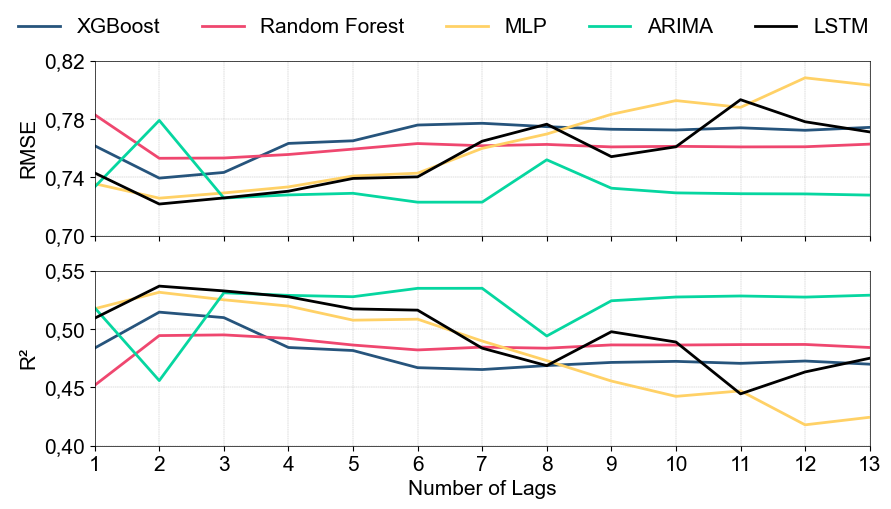

In [ ]:
fig_all_models_lags, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(lags, rmse_list_xgb, label='XGBoost', c='#26547C')
ax[0].plot(lags, rmse_list_rf, label='Random Forest', c='#EF476F')
ax[0].plot(lags, rmse_list_mlp, label='MLP', c="#FFD166")
ax[0].plot(lags_arma, rmse_list_arma, label='ARMA', c='#06D6A0')
ax[0].plot(lags, rmse_list_lstm, label='LSTM', c="k")

ax[1].plot(lags, r2_list_xgb, label='XGBoost', c='#26547C')
ax[1].plot(lags, r2_list_rf, label='Random Forest', c='#EF476F')
ax[1].plot(lags, r2_list_mlp, label='MLP', c='#FFD166')
ax[1].plot(lags_arma, r2_list_arma, label='ARIMA', c='#06D6A0')
ax[1].plot(lags, r2_list_lstm, label='LSTM', c='k')

ax[0].set_ylabel('RMSE')
ax[1].set_ylabel('R²')
ax[1].set_xlabel('Number of Lags')

ax[0].legend(ncols=5, loc='upper center', bbox_to_anchor=(0.45, 1.35), frameon=False)
ax[1].set_xticks(range(1, 14))
ax[1].set_xlim(1, 13)

ax[0].set_yticks(np.arange(0.7, 0.83, 0.04))
ax[1].set_yticks(np.arange(0.4, 0.55, 0.05))

ax[0].grid(lw=0.3) 
ax[1].grid(lw=0.3) 

plt.show()

In [ ]:
print(f'Average RMSE across folds: {np.mean(scores)}')
print(f'RMSE scores for each fold: {scores}')
print(f"Melhor modelo: Fold {best_fold} | RMSE = {best_rmse:.4f}")

Average RMSE across folds: 0.6921170197931963
RMSE scores for each fold: [0.7079480434751928, 0.7552039915329253, 0.6149589948728331, 0.6403161289322098, 0.7421579401528205]
Melhor modelo: Fold 2 | RMSE = 0.6150


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.2f}')

Root Mean Squared Error: 0.74
Mean Absolute Error: 0.52
R^2 Score: 0.62


### 4.1 - Ploting Model Results

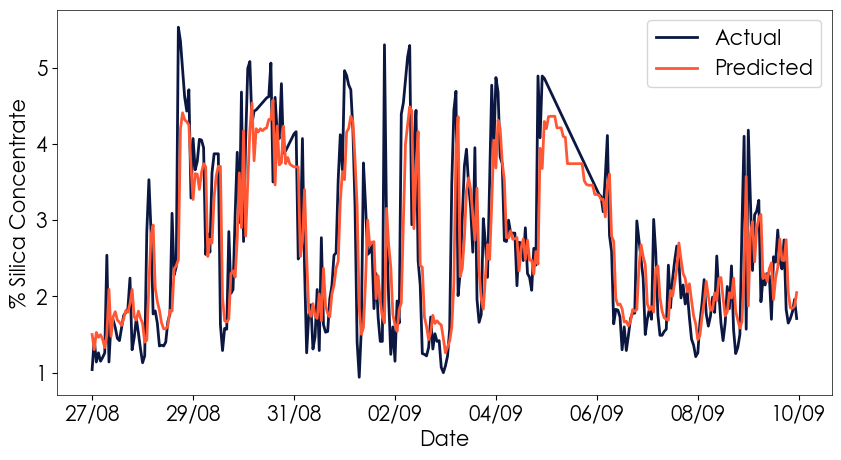

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(y_test.index, y_test, label='Actual', c='#0B1741')
ax.plot(y_test.index, y_pred, label='Predicted', c='#FF5733')   

ax.set_ylabel('% Silica Concentrate')
ax.set_xlabel('Date')
ax.legend(loc='upper right')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

ax.set_xticks([pd.Timestamp('2017-08-27'), pd.Timestamp('2017-08-29'), pd.Timestamp('2017-08-31'), pd.Timestamp('2017-09-02'),
               pd.Timestamp('2017-09-04'), pd.Timestamp('2017-09-06'), pd.Timestamp('2017-09-08'), pd.Timestamp('2017-09-10')])

# fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\fm_sc_prediction.svg', dpi=140, format='svg', transparent=True)

plt.show()

In [ ]:
results = model.evals_result_
print(results.keys())

AttributeError: 'XGBRegressor' object has no attribute 'evals_result_'

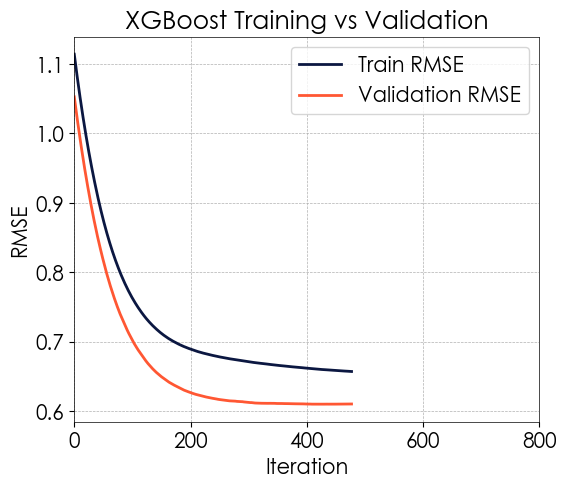

In [ ]:
train_rmse = results['validation_0']['rmse']
val_rmse   = results['validation_1']['rmse']

fig_error, ax = plt.subplots(figsize=(6, 5))

ax.plot(train_rmse, label='Train RMSE', c='#0B1741')
ax.plot(val_rmse, label='Validation RMSE', c='#FF5733')

ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Training vs Validation')
ax.legend()

ax.grid(True)
ax.set_xlim(0, 800)

# fig_error.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\fm_sc_errors_02.svg', dpi=140, format='svg', transparent=True)

plt.show()

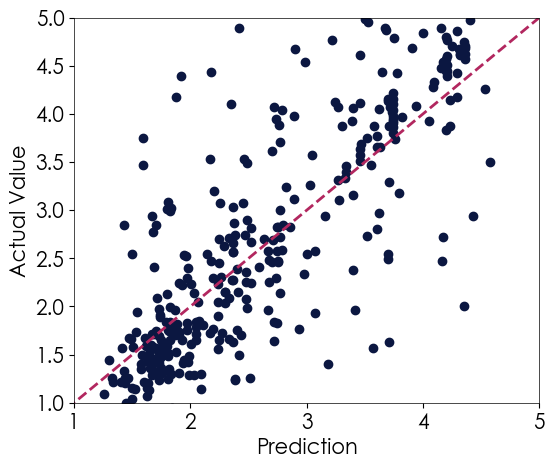

In [ ]:
fig_scatter_error, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_pred, y_test, c='#0B1741')
ax.plot([0, 5], [0, 5], color='#B2275F', ls='--')

ax.set_xlabel('Prediction')
ax.set_ylabel('Actual Value')

ax.set_ylim(1, 5)
ax.set_xlim(1, 5)

plt.show()

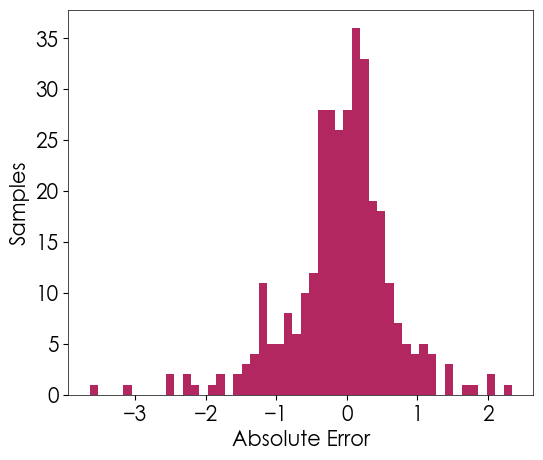

In [ ]:
fig_hist_error, ax = plt.subplots(figsize=(6, 5))

ax.hist(y_pred - y_test, bins=50, color='#B2275F')

ax.set_xlabel('Absolute Error')
ax.set_ylabel('Samples')

plt.show()

# 05 - Predicting the Future

In [ ]:
future = 24 * 2 # in hours (1 day)

X_test_future = X_test.iloc[-future:]

In [ ]:
for i in range(future):
    if i == 0:
        y_pred_future = model.predict(X_test_future.iloc[[i]])
    else:
        X_test_future.iloc[[i], 0] = y_pred_future
        
        print(y_pred_future)
        for j in range(1, X_test_future.shape[1] - 1):
            X_test_future.iloc[[i], j] = X_test_future.iloc[[i], j + 1]
        
        y_pred_future = model.predict(X_test_future.iloc[[i]])

In [ ]:
y_test_future = y_test.iloc[-future:].copy()

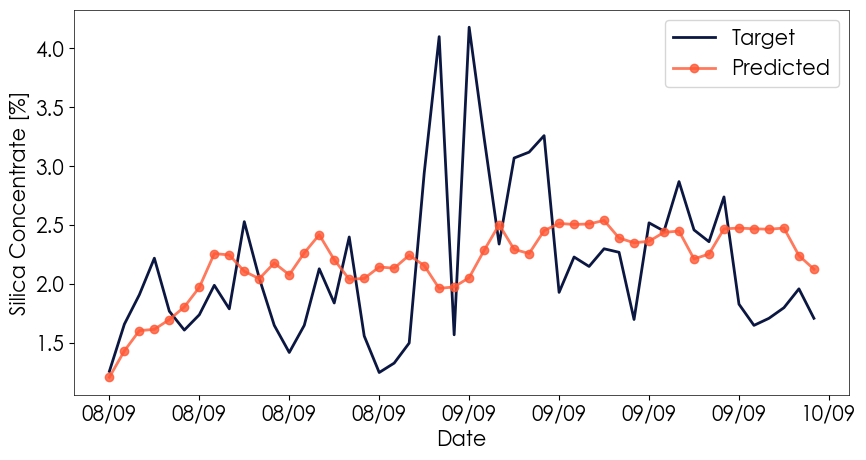

In [ ]:
fig_fut, ax = plt.subplots(figsize=(10, 5))

ax.plot(y_test_future, c='#0B1741', label='Target')
ax.plot(X_test_future.index, X_test_future['lag-1'], c='#FF5733', label='Predicted', marker='o', alpha=0.8)

ax.set_ylabel('Silica Concentrate [%]')
ax.set_xlabel('Date')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

ax.legend()

# fig_fut.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\future-predict.svg', dpi=140, format='svg', transparent=True)

plt.show()

The chart demonstrates that the model is capable of predicting up to a 3-hour horizon with relative low errors.

---